In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../Data/demand_forecasting.csv')

# Data Cleaning & Data Understanding

## Objective

The objective of this phase is to assess data quality, identify missing values, validate data types, detect duplicates, and ensure the dataset is suitable for further analysis and demand forecasting.

In [3]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
df.shape

(76000, 16)

In [5]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [7]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [8]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [9]:
(df.isnull().sum()/len(df))*100

Date                  0.0
Store ID              0.0
Product ID            0.0
Category              0.0
Region                0.0
Inventory Level       0.0
Units Sold            0.0
Units Ordered         0.0
Price                 0.0
Discount              0.0
Weather Condition     0.0
Promotion             0.0
Competitor Pricing    0.0
Seasonality           0.0
Epidemic              0.0
Demand                0.0
dtype: float64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df['Date'] = pd.to_datetime(df['Date'])

In [13]:
df.dtypes

Date                  datetime64[us]
Store ID                         str
Product ID                       str
Category                         str
Region                           str
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition                str
Promotion                      int64
Competitor Pricing           float64
Seasonality                      str
Epidemic                       int64
Demand                         int64
dtype: object

In [14]:
cat_cols = ['Category',
            'Region',
            'Weather Condition',
            'Promotion',
            'Seasonality',
            'Epidemic']

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Category
Category
Groceries      30400
Furniture      13680
Clothing       12160
Toys           10640
Electronics     9120
Name: count, dtype: int64

Region
Region
North    30400
South    15200
East     15200
West     15200
Name: count, dtype: int64

Weather Condition
Weather Condition
Cloudy    24360
Sunny     22980
Rainy     17500
Snowy     11160
Name: count, dtype: int64

Promotion
Promotion
0    51000
1    25000
Name: count, dtype: int64

Seasonality
Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtype: int64

Epidemic
Epidemic
0    60800
1    15200
Name: count, dtype: int64


In [15]:
num_cols = [
    'Inventory Level',
    'Units Sold',
    'Units Ordered',
    'Price',
    'Discount',
    'Competitor Pricing',
    'Demand'
]

In [16]:
df[num_cols].describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,69.454029,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,40.943818,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,4.290000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,32.620000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,65.700000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,97.932500,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,261.220000,430.000000


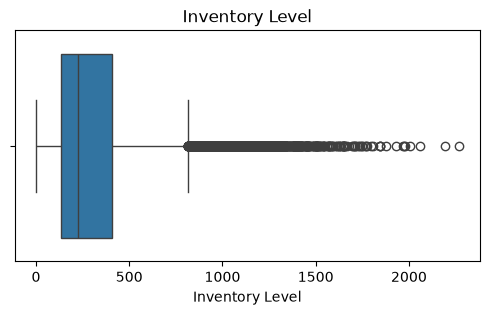

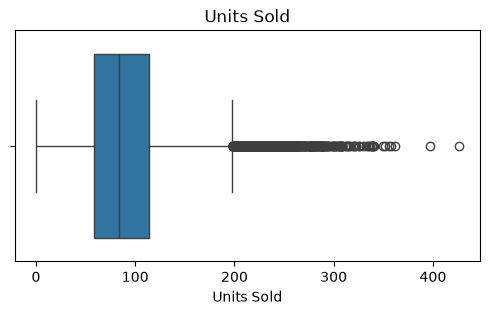

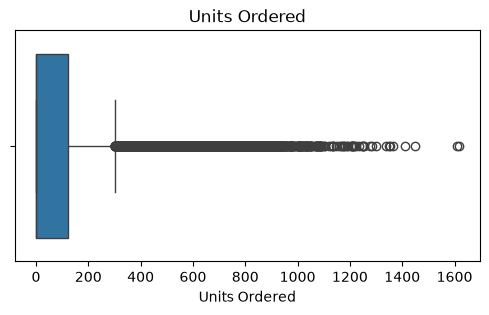

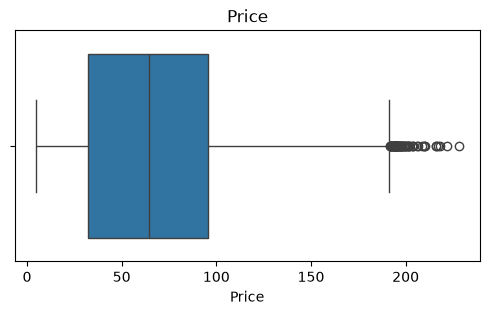

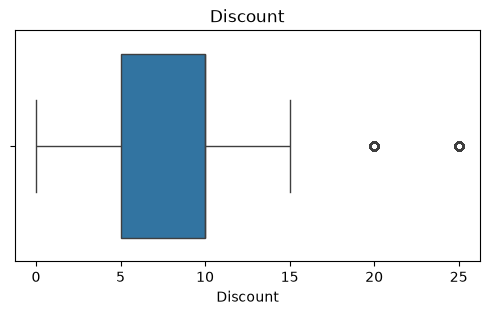

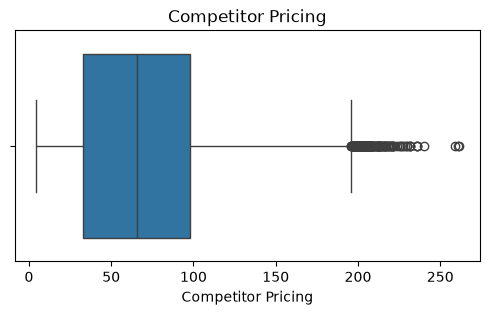

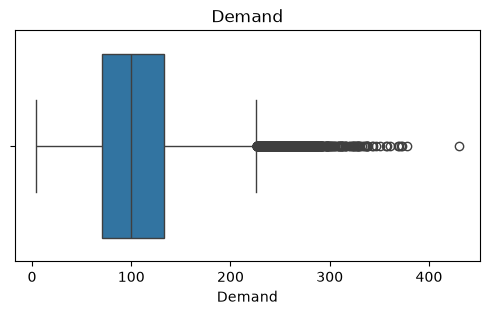

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [18]:
df['Date'].min()

Timestamp('2022-01-01 00:00:00')

In [19]:
df['Date'].max()

Timestamp('2024-01-30 00:00:00')

In [20]:
df['Date'].nunique()

760

In [21]:
(df['Inventory Level'] < 0).sum()

np.int64(0)

In [22]:
(df['Price'] < 0).sum()

np.int64(0)

In [23]:
(df['Demand'] < 0).sum()

np.int64(0)

In [24]:
(df['Units Sold'] < 0).sum()

np.int64(0)

## Data Cleaning Summary

### Key Findings

- Dataset contains 76,000 records and 16 features.
- No missing values were found.
- No duplicate records were detected.
- All numerical columns were properly formatted.
- Date column was converted from string to datetime format.
- Dataset covers the period from January 2022 to January 2024.
- Data quality checks confirmed there are no invalid negative values in key business metrics.

### Conclusion

The dataset is clean, complete, and ready for Exploratory Data Analysis (EDA) and demand forecasting.

In [25]:
df['Category'].value_counts()

Category
Groceries      30400
Furniture      13680
Clothing       12160
Toys           10640
Electronics     9120
Name: count, dtype: int64

In [26]:
df['Region'].value_counts()

Region
North    30400
South    15200
East     15200
West     15200
Name: count, dtype: int64

In [27]:
df['Weather Condition'].value_counts()

Weather Condition
Cloudy    24360
Sunny     22980
Rainy     17500
Snowy     11160
Name: count, dtype: int64

In [28]:
df['Seasonality'].value_counts()

Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtype: int64

In [29]:
df['Promotion'].value_counts()

Promotion
0    51000
1    25000
Name: count, dtype: int64

In [30]:
df['Epidemic'].value_counts()

Epidemic
0    60800
1    15200
Name: count, dtype: int64